# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...
[########################################] | 100% Completed | 103.34 ms
Processing leg 0...
[########################################] | 100% Completed | 4.93 ss
Processing leg 1...
[########################################] | 100% Completed | 4.13 ss
Debugging output...
Plotting leaf and wood points to check classification...


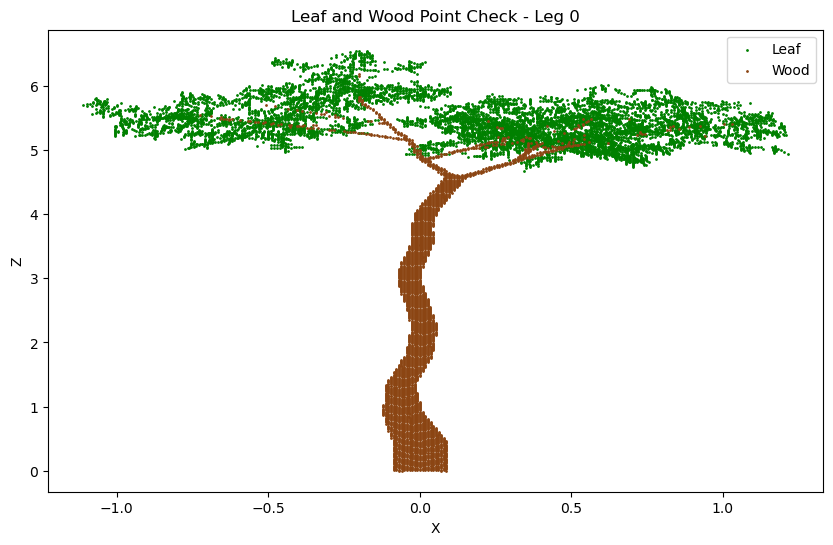

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

return_numbers: nan
number_f_returns: nan
hit_type: 3


In [1]:
import os
import glob
from utils import prepare_helios_data

# Set up the project directory
project_dir = '/home/capheus/projects/single_test'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

valid_rays_dir = os.path.join(project_dir, 'valid_rays')
if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir)

# Establish the object IDs for the leaves
leaf_object_ids = [1]
wood_object_ids = [0]

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=True,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [2]:
import os
import glob
from utils import add_normals_weights_to_valid_rays

valid_rays_dir = "/home/capheus/projects/single_test/valid_rays"
valid_ray_parquets = glob.glob(os.path.join(valid_rays_dir, "*valid_rays.parquet"))

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_ray_parquets, 
    debug=True,
    knn=6
)

Adding normals and weights to 2 files...
[########################################] | 100% Completed | 3.34 ss


Estimating normals/weights per voxel: 100%|██████████| 2/2 [00:00<00:00, 17.71it/s]


Debugging enabled:
     leg_id  ray_id  origin_x  origin_y  origin_z  direction_x  direction_y  \
28        0     129       0.0     -10.0       3.5         -0.0       0.9767   
105       0     131       0.0     -10.0       3.5         -0.0       0.9760   
116       0     132       0.0     -10.0       3.5         -0.0       0.9756   
128       0     133       0.0     -10.0       3.5         -0.0       0.9753   
160       0      86       0.0     -10.0       3.5         -0.0       0.9896   

     direction_z  point_x  point_y  point_z  echo_intensity  return_number  \
28        0.2145  -0.0005   0.7846   5.8680      4005782.00            1.0   
105       0.2177  -0.0005   0.3333   5.8052      3865344.75            1.0   
116       0.2194  -0.0005   0.3288   5.8224      3872678.50            1.0   
128       0.2210  -0.0005   0.3188   5.8383      3880005.25            1.0   
160       0.1436  -0.0003   0.0595   4.9596      3827520.50            1.0   

     number_of_returns  normal_x  nor

## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [1]:
import os
from utils import voxel_ray_intersections

# Set up the project directory
project_dir = '/home/capheus/projects/single_test'
valid_rays_dir = os.path.join(project_dir, 'valid_rays')
references_dir = os.path.join(project_dir, 'references')

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir
)

Queuing map_partitions tasks...
Number of partitions: 3, Number of rays: 6746368, Number of voxels: 18, Rays per chunk: 2823446, Voxels per chunk: 7, Number of chunks: 2
Queuing map_partitions tasks...
Number of partitions: 3, Number of rays: 6746368, Number of voxels: 18, Rays per chunk: 2823138, Voxels per chunk: 7, Number of chunks: 2
Processing leg 0...
[##########################              ] | 66% Completed | 86.12 sProcess c1e35f3462264a38b441f2fe93a9c569. Returning results...
[###############################         ] | 77% Completed | 86.31 sProcess c12c290685be488ca06e1186f37c6b02. Returning results...
[########################################] | 100% Completed | 86.42 s
Saving results for leg 0...
Completed leg 0!
Processing leg 1...
[######################                  ] | 55% Completed | 10.93 sProcess fda05ab7787f4f6c8688188b27e8f166. Returning results...
[###############################         ] | 77% Completed | 12.58 sProcess 8ae3131e50224e3783eef7d49138f42d. Re

### CHECKER


In [2]:
import os
import glob
import pandas as pd

valid_rays_dir = "/home/capheus/projects/single_test/valid_rays"

intersection_files = glob.glob(os.path.join(valid_rays_dir, "*_intersections.parquet"))
for file in intersection_files:
    df = pd.read_parquet(file)
    print(df.head())
    num_unbound_rays = df[df['hit_type'] == 0].shape[0]
    num_previous_hit_rays = df[df['hit_type'] == 1].shape[0]
    num_current_hit_rays = df[df['hit_type'] == 2].shape[0]
    num_yet_to_hit_rays = df[df['hit_type'] == 3].shape[0]
    print(f"unbound: {num_unbound_rays}")
    print(f"previous hit: {num_previous_hit_rays}")
    print(f"current hit: {num_current_hit_rays}")
    print(f"yet to hit: {num_yet_to_hit_rays}")

    num_leaf_hits = df[df['is_leaf'] == True].shape[0]
    print(f"leaf hits: {num_leaf_hits}")

   voxel_size    voxel_id  leg_id  ray_id  t_entry_x  t_entry_y  t_entry_z  \
0         1.0  2685580705       0   31063  -0.266996  -0.737141   5.747535   
1         1.0  2685580705       0   31064  -0.267106  -0.737141   5.763724   
2         1.0  2685580705       0   31065  -0.267216  -0.737141   5.779927   
3         1.0  2685580705       0   31066  -0.267326  -0.737141   5.797098   
4         1.0  2685580705       0   31067  -0.267437  -0.737141   5.813327   

   t_exit_x  t_exit_y  t_exit_z  ...  echo_intensity  return_number  \
0 -0.295821  0.262864  5.990176  ...      7597938.50            1.0   
1 -0.294986  0.229676  6.000002  ...      3224203.50            1.0   
2 -0.293010  0.156977  6.000002  ...      2274509.75            1.0   
3 -0.290940  0.081055  6.000002  ...      2310918.75            1.0   
4 -0.289018  0.010330  6.000002  ...      3790182.75            1.0   

   number_of_returns  normal_x  normal_y  normal_z  point_weight  \
0                1.0  0.827137 -0.55

## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

### Step 3.1 - Multi-return
Use the get_voxel_metrics_multireturn function to handle mutli return projects.

In [ ]:
import os
import glob
import utils
import pandas as pd

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = [2.0] # 'all' # [0.2, 0.5, 1.0, 2.0]

# Set the average leaf area
average_leaf_area = 0.02  # in m^2, adjust as needed

# Set up the project directory
project_dir = '/home/capheus/projects/200_leaf_60_JoshOutput'
valid_rays_dir = os.path.join(project_dir, 'valid_rays')
references_dir = os.path.join(project_dir, 'references')
# Set up the output directory
output_dir = os.path.join(project_dir, 'results')

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = utils.calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    ### TEST
    lambda_1 = 0.00030701925

    # Calculate per voxel information from all files
    voxel_metrics_df = utils.get_voxel_metrics_multireturn(intersections_files=files, lambda_1=lambda_1, is_leaf_true=True)

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*voxel_size_{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
    df_ref = df_ref.add_suffix('_ref')

    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id', 
        'voxel_cx_ref': 'voxel_cx',
        'voxel_cy_ref': 'voxel_cy',
        'voxel_cz_ref': 'voxel_cz',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    # Merge to maintain voxel_id matching
    voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')

    # Add lambda_1 to the dataframe
    voxel_metrics_df['lambda_1'] = lambda_1

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    legs.sort()
    leg_string = "_".join(map(str, legs))
    output_file = os.path.join(output_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 2.0, Lambda_1: 0.0025
[########################################] | 100% Completed | 618.41 ms
